In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('customer_info.csv')

In [3]:
df

,customer_id,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,...,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
0,3,Bsc. Crystal Kitchens,female,02/12/1970 01:36 PM,1.0,1.0,1.0,3.0,11731.0,4553.0,...,213.0,552.0,256.0,384.0,189.0,0.631599,2020.0,1.0,38.794428,-9.215739
1,4,Bsc. Glenda Bauman,female,11/13/1975 06:58 PM,1.0,0.0,0.0,2.0,13694.0,963.0,...,15.0,1880.0,333.0,665.0,130.0,0.149890,2013.0,1.0,38.751711,-9.179611
2,5,Msc. Antonio Campbell,male,09/10/1971 10:07 AM,0.0,0.0,NaN,2.0,12407.0,0.0,...,273.0,507.0,101.0,222.0,81.0,0.069126,2005.0,NaN,38.780678,-9.160656
3,7,John Kelling,male,10/23/1982 11:20 AM,0.0,0.0,2.0,1.0,7493.0,1105.0,...,1083.0,485.0,1656.0,184.0,92.0,0.253609,2021.0,1.0,38.739548,-9.148679
4,8,Arthur Dematteo,male,08/04/1969 10:22 PM,0.0,0.0,3.0,1.0,9187.0,10841.0,...,1015.0,297.0,1258.0,441.0,6.0,0.186569,2021.0,1.0,38.733071,-9.188188
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33033,39996,Joshua Howard,male,05/16/1973 02:04 PM,0.0,0.0,2.0,1.0,475.0,13488.0,...,1154.0,62.0,1598.0,366.0,162.0,0.261352,2014.0,NaN,38.742306,-9.163971
33034,39997,Anthony Hines,male,05/10/1955 01:19 AM,1.0,0.0,1.0,1.0,8430.0,14408.0,...,602.0,220.0,2105.0,227.0,97.0,0.143479,2014.0,NaN,38.748505,-9.193445
33035,39998,Edna Hasselman,female,05/15/1945 11:09 PM,1.0,1.0,0.0,4.0,8029.0,1480.0,...,NaN,1719.0,89.0,258.0,206.0,0.181917,2012.0,NaN,38.776003,-9.137943
33036,39999,George Kramer,male,05/25/1951 09:02 PM,1.0,1.0,1.0,6.0,8364.0,3114.0,...,113.0,410.0,NaN,225.0,385.0,0.807259,2017.0,NaN,38.736034,-9.145235


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33038 entries, 0 to 33037
Data columns (total 26 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   customer_id                              33038 non-null  int64         
 1   customer_name                            33038 non-null  object        
 2   customer_gender                          33038 non-null  object        
 3   customer_birthdate                       32873 non-null  datetime64[ns]
 4   kids_home                                32708 non-null  float64       
 5   teens_home                               32708 non-null  float64       
 6   number_complaints                        32377 non-null  float64       
 7   distinct_stores_visited                  32708 non-null  float64       
 8   lifetime_spend_groceries                 33038 non-null  float64       
 9   lifetime_spend_electronics             

C:\Users\pedro\AppData\Local\Temp\ipykernel_21636\759582923.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='customer_gender', ax=axes[0, 0], palette='viridis')
C:\Users\pedro\AppData\Local\Temp\ipykernel_21636\759582923.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=spend_summary.values, y=spend_summary.index, palette='magma')


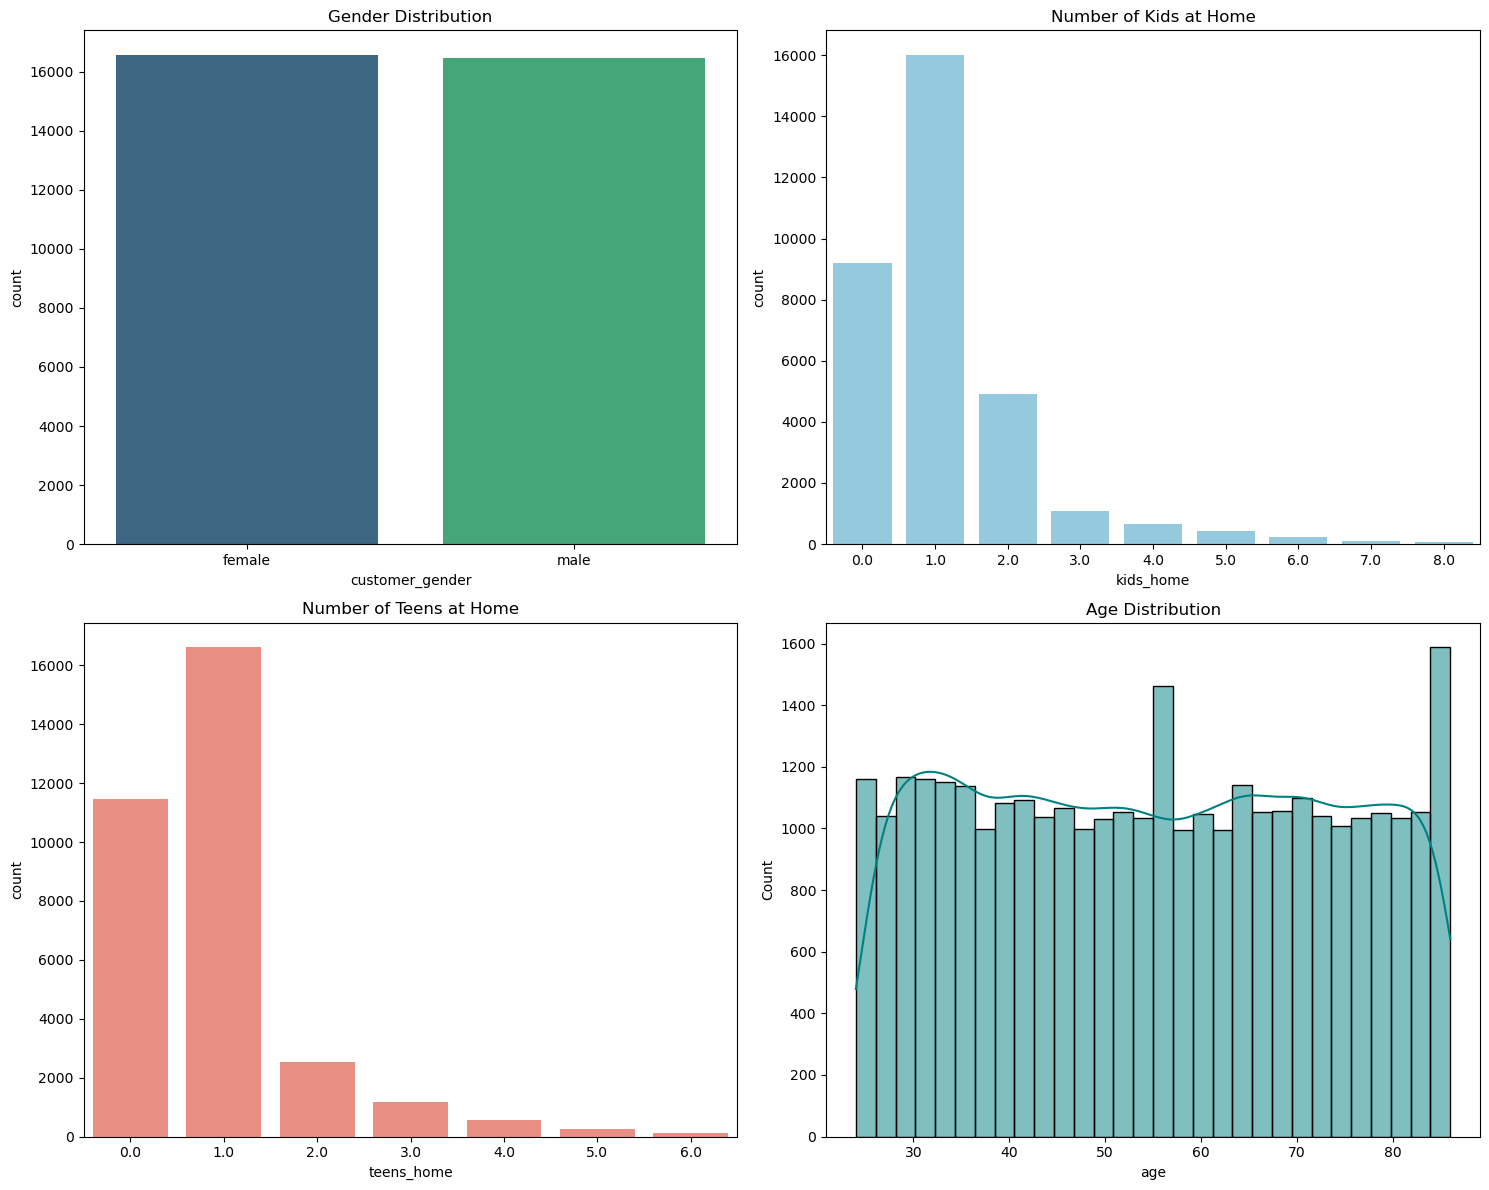

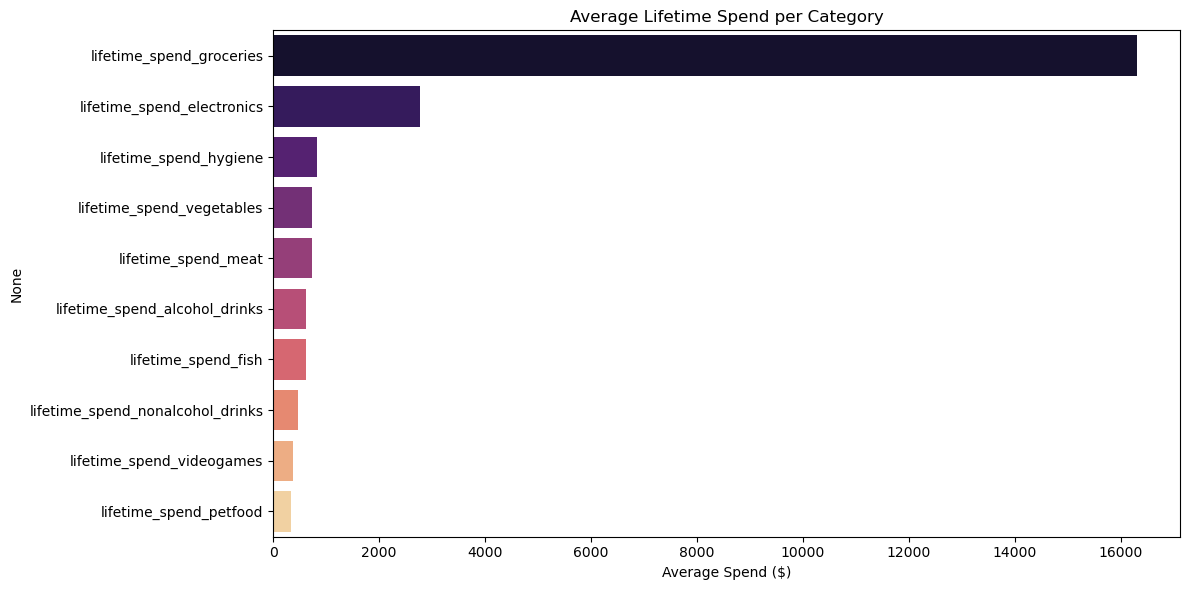

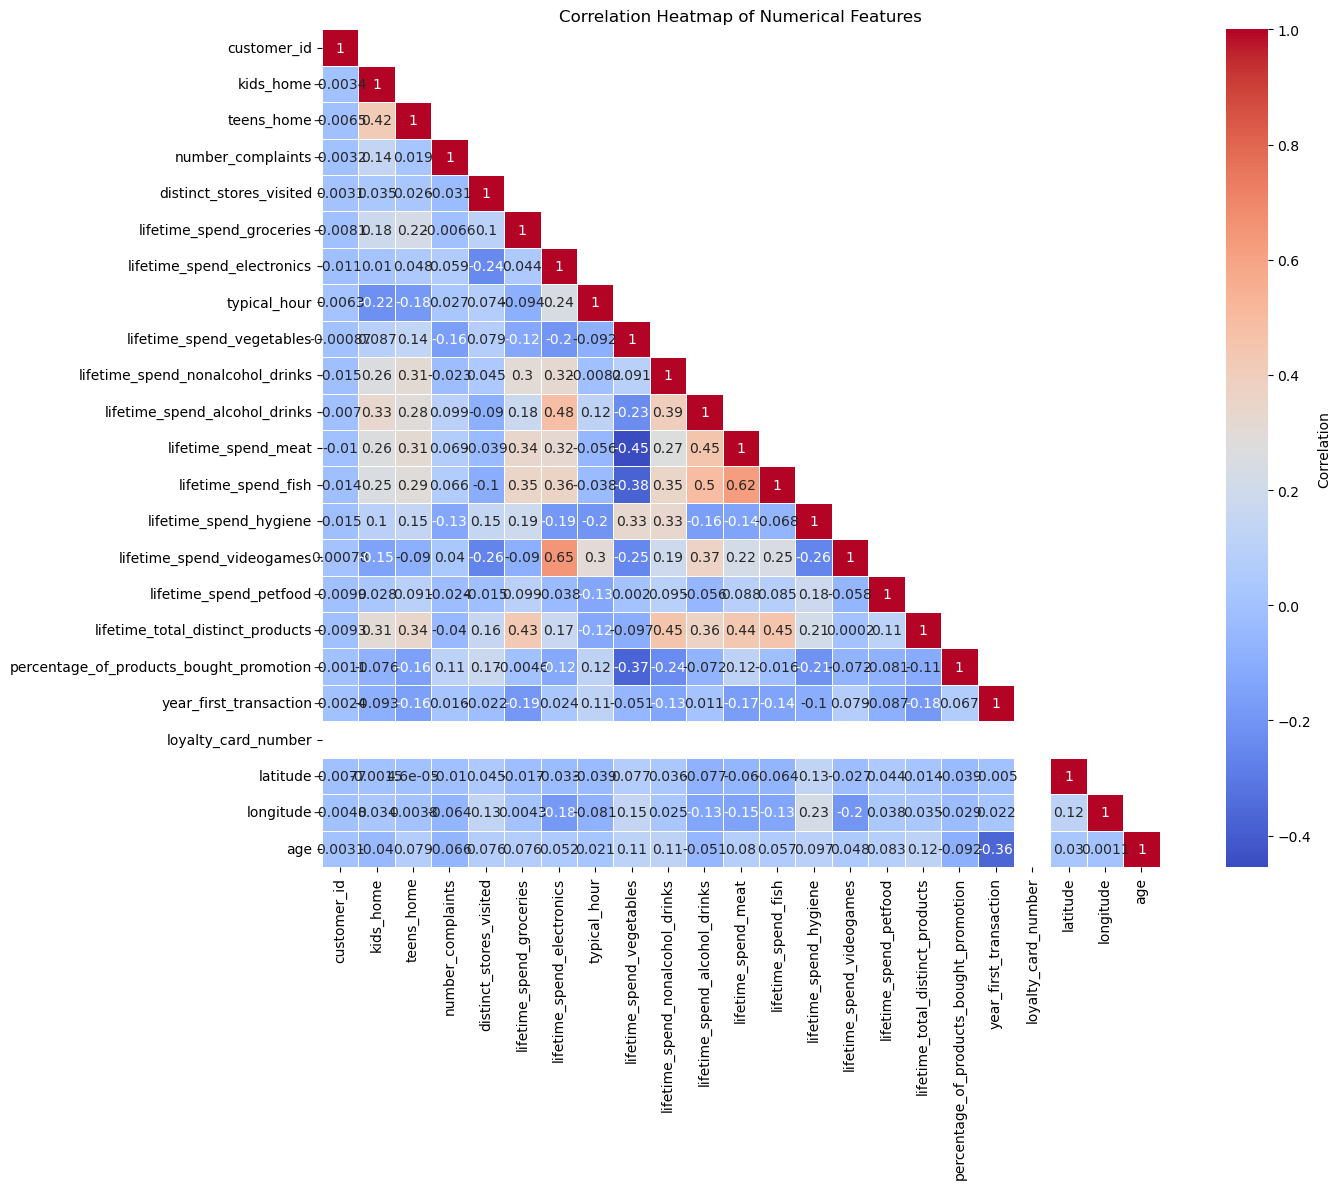

In [7]:
print(df.info())
print(df.isnull().sum().sort_values(ascending=False))

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Gender Distribution
sns.countplot(data=df, x='customer_gender', ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Gender Distribution')

# Kids at Home
sns.countplot(data=df, x='kids_home', ax=axes[0, 1], color='skyblue')
axes[0, 1].set_title('Number of Kids at Home')

# Teens at Home
sns.countplot(data=df, x='teens_home', ax=axes[1, 0], color='salmon')
axes[1, 0].set_title('Number of Teens at Home')

# Age Distribution
sns.histplot(df['age'].dropna(), bins=30, kde=True, ax=axes[1, 1], color='teal')
axes[1, 1].set_title('Age Distribution')

plt.tight_layout()

# 5. Spending Summary Visualization
# Identify all columns related to lifetime spend
spend_cols = [col for col in df.columns if 'lifetime_spend' in col]
spend_summary = df[spend_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=spend_summary.values, y=spend_summary.index, palette='magma')
plt.title('Average Lifetime Spend per Category')
plt.xlabel('Average Spend ($)')
plt.tight_layout()

numerical_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numerical_cols].corr()

# Create mask to show only upper triangle (eliminate duplicates)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5, mask=mask, square=True, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
